In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
df = pd.read_csv('mercedes_benz_listings_cleaned.csv')
features = ['Mileage_Miles']
n_features = len(features)
#prepare data
data = df.dropna()



idx_train = data.sample(frac = 0.8).index

X_train = data.loc[idx_train,features].values
Y_train = data.loc[idx_train,'Price_USD'].values

X_test = data.drop(idx_train).loc[:,features].values
Y_test = data.drop(idx_train)['Price_USD'].values

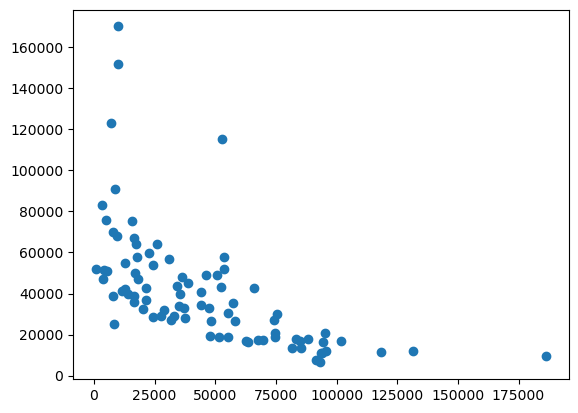

In [2]:
plt.scatter(X_train,Y_train)

# FEATURES SCALING

In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled

array([[ 1.22882221],
       [ 1.38036514],
       [-0.82801273],
       [ 0.15680054],
       [-0.04270557],
       [ 0.01915456],
       [ 0.17814948],
       [ 2.09218822],
       [ 0.23684467],
       [ 0.36220495],
       [-1.10833982],
       [-0.83802544],
       [ 1.40677798],
       [-0.04106556],
       [ 0.83760724],
       [-1.15854723],
       [-0.93662761],
       [-1.04026491],
       [-0.68567689],
       [ 0.211295  ],
       [-0.79679494],
       [ 1.13729799],
       [ 0.59456886],
       [ 1.09313273],
       [-1.28986334],
       [ 0.28696576],
       [-1.08523578],
       [-0.90405753],
       [ 0.6313109 ],
       [-0.2872401 ],
       [-0.26894101],
       [-0.23832744],
       [-1.21718488],
       [-1.02199459],
       [-0.83710473],
       [ 1.44084421],
       [ 1.61776418],
       [ 2.47972036],
       [-0.69672539],
       [-0.51131764],
       [ 1.37794828],
       [-1.02423882],
       [-0.39850202],
       [ 0.86266778],
       [-0.22428663],
       [ 1

In [4]:
Y_train = Y_train.reshape([X_train.shape[0],1])

X_trainb = np.hstack([X_train_scaled,np.ones((X_train.shape[0],1))])

# Polynomial application

In [5]:
from sklearn.preprocessing import PolynomialFeatures
X_poly = PolynomialFeatures(degree=2,include_bias=True).fit_transform(X_train_scaled)
X_poly.shape[1]

3

# LINEAR REGRESSION CLASS

In [6]:
class LR :
    def __init__(self,n_features,ridge_lamda = 0):
        self.w = np.random.randn(n_features,1)
        self.costs = []
        self.lamda = ridge_lamda

    def predict(self,X):
        return X@self.w

    def cost(self, X,y):
        m = len(y)
        ridge = self.lamda * np.sum(self.w **2)
        return (1/(2*m)) * (np.sum((X@self.w - y) **2) + ridge)

    def grad(self,X,y):
        m = len(y)
        ridge = self.lamda * self.w
        return (1/m) * ( X.T.dot(X@self.w - y) + ridge)

    def descente_gradient(self,X,y,alpha,n_iterations):
        for i in range(0,n_iterations):
            self.w = self.w -alpha * self.grad(X,y)
            self.costs.append(self.cost(X,y))

    def fit_analytique(self,X,y):
        self.w = 0
        self.w = np.linalg.inv(X.T@X).dot(X.T@y)
        

In [7]:
lr = LR(X_poly.shape[1])
lr.descente_gradient(X_poly,Y_train,alpha=0.1,n_iterations=1000)

lr2 = LR(n_features)
lr2.fit_analytique(X_trainb,Y_train)

predictions =lr.predict(X_poly)
predictions2  = lr2.predict(X_trainb)

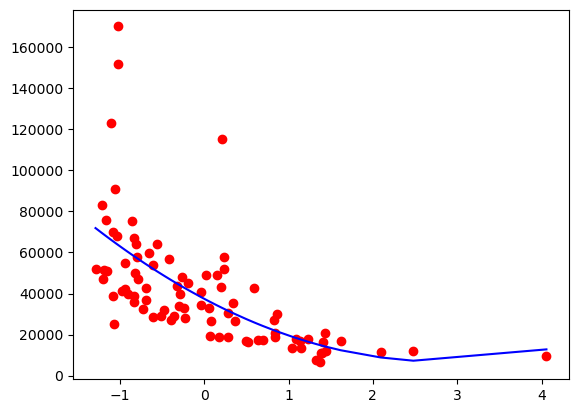

In [8]:
idx = np.argsort(X_train_scaled[:,0])

X_sorted = X_train_scaled[idx]
pred_sorted = predictions[idx]

plt.scatter(X_train_scaled, Y_train, c='red')
plt.plot(X_sorted, pred_sorted, color='blue')

In [9]:
from sklearn.metrics import r2_score
df = pd.DataFrame({
    'prediction' : [r2_score(Y_train,predictions)],
    'prediction2' : [r2_score(Y_train,predictions2)]
    })
print(np.allclose(predictions,predictions2))
df

False


,prediction,prediction2
0,0.403494,0.360007


# sklearn model

In [10]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression

model = make_pipeline(StandardScaler(), LinearRegression())
model.fit(X_train, Y_train)

pred = model.predict(X_train)
print(r2_score(Y_train,pred))

0.36000727936590027
